# **Assignment-1**

In [1]:
import numpy as np
import pandas as pd

###`Q-1:` Write a program to create an empty series.

In [4]:
# code here
s1=pd.Series()
print(type(s1))

<class 'pandas.core.series.Series'>


###`Q-2:` Write a Pandas program to add, subtract, multiple and divide two Pandas Series.

In [6]:
# code here
s1=pd.Series([2,4,6,8,10])
s2=pd.Series([1,3,5,7,9])
add=s1+s2
print(add)
prod=s1*s2
print(prod)
sub=s1-s2
print(sub)
div=s1/s2
print(div)

0     3
1     7
2    11
3    15
4    19
dtype: int64
0     2
1    12
2    30
3    56
4    90
dtype: int64
0    1
1    1
2    1
3    1
4    1
dtype: int64
0    2.000000
1    1.333333
2    1.200000
3    1.142857
4    1.111111
dtype: float64


###`Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [7]:
# code here
s1=pd.Series([2,4,6,8,10])
s2=pd.Series([1,3,5,7,10])
print(s1==s2)

0    False
1    False
2    False
3    False
4     True
dtype: bool


###`Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [12]:
# code here
series = pd.Series([1,2,'Python', 2.0, True, 100])
def typeconv(value):
  try:
        converted_value = float(value)
        return converted_value
  except ValueError:
        # Handle cases where the value cannot be converted to a float
        return value
s=series.apply(typeconv)
display(s)

,0
0,1.0
1,2.0
2,Python
3,2.0
4,1.0
5,100.0


Download data - https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link
All Batsman runs series in IPL 2008 to 2022.

Below questions are based on this data.

In [18]:
s = pd.read_csv('/content/batsman_runs_series.csv', index_col='batter').squeeze('columns')

In [19]:
s

,batsman_run
batter,
A Ashish Reddy,280
A Badoni,161
A Chandila,4
A Chopra,53
A Choudhary,25
...,...
Yash Dayal,0
Yashpal Singh,47
Younis Khan,3


###`Q-6` Find top 10 most run getter from the series.

In [21]:
# code here
s.sort_values(ascending=False).head(10)

,batsman_run
batter,
V Kohli,6634
S Dhawan,6244
DA Warner,5883
RG Sharma,5881
SK Raina,5536
AB de Villiers,5181
CH Gayle,4997
MS Dhoni,4978
RV Uthappa,4954


###`Q-7` No of players having runs above 3000

In [26]:
# code here
s[s>3000]

,batsman_run
batter,
AB de Villiers,5181
AM Rahane,4074
AT Rayudu,4190
CH Gayle,4997
DA Warner,5883
F du Plessis,3403
G Gambhir,4217
KA Pollard,3437
KD Karthik,4377


###`Q-8` No of players having runs above mean value?

In [28]:
s.mean()

np.float64(464.42809917355373)

In [27]:
# code here
s[s>s.mean()]

,batsman_run
batter,
A Symonds,974
AB de Villiers,5181
AC Gilchrist,2069
AD Mathews,724
AD Russell,2039
...,...
WP Saha,2427
Y Venugopal Rao,985
YBK Jaiswal,547


Download data - https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv



###`Q-9`
    i. Read `items.csv` making `item_name` as index.
    ii. Show no of nan values
    ii. Item price is given in $, so convert it to rupees without currency symbol.
    iii. Make data type of newly made series as float.
    iv. Fill nan with mean of the series


How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

In [43]:
item=pd.read_csv('/content/items.csv',index_col='item_name')
item

,item_price
item_name,
Chips and Fresh Tomato Salsa,$2.39
Izze,$3.39
Nantucket Nectar,$3.39
Chips and Tomatillo-Green Chili Salsa,$2.39
Chicken Bowl,$16.98
...,...
Steak Burrito,$11.75
Steak Burrito,$11.75
Chicken Salad Bowl,$11.25


In [44]:
# Remove '$' sign and convert to float
item['item_price'] = item['item_price'].astype(str).str.replace('$', '', regex=False).str.strip()
item['item_price'] = pd.to_numeric(item['item_price'], errors='coerce')

# Display the updated DataFrame
display(item.head())

,item_price
item_name,
Chips and Fresh Tomato Salsa,2.39
Izze,3.39
Nantucket Nectar,3.39
Chips and Tomatillo-Green Chili Salsa,2.39
Chicken Bowl,16.98


In [45]:
item['item_price']=item['item_price']*82
item.head()

,item_price
item_name,
Chips and Fresh Tomato Salsa,195.98
Izze,277.98
Nantucket Nectar,277.98
Chips and Tomatillo-Green Chili Salsa,195.98
Chicken Bowl,1392.36


In [47]:
# Handling missing values:
item.isnull().sum()
mean_price = item['item_price'].mean()
item['item_price'].fillna(mean_price, inplace=True)

/tmp/ipython-input-1073613512.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  item['item_price'].fillna(mean_price, inplace=True)


In [48]:
item.isnull().sum()

,0
item_price,0


###`Q-10`:
    i. Find mean price
    ii. Find 30th and 6th percentile value
    iii. Plot Histogram on price with bin size 50
    iv. No of items price lies between [1000 to 2000]



In [49]:
# code here
item['item_price'].mean()

np.float64(611.9685826771653)

In [50]:
# Find 30th and 6th percentile values
percentile_30 = item['item_price'].quantile(0.3)
percentile_6 = item['item_price'].quantile(0.06)

print(f"30th percentile of item price: {percentile_30}")
print(f"6th percentile of item price: {percentile_6}")

30th percentile of item price: 364.90000000000003
6th percentile of item price: 102.5


<Axes: ylabel='Frequency'>

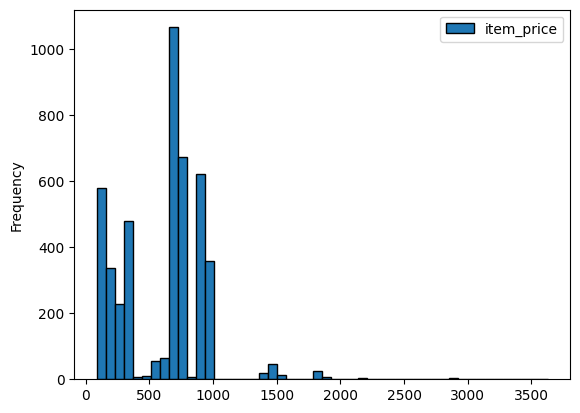

In [51]:
item.plot(kind='hist', y='item_price', bins=50, edgecolor='black')

In [55]:
item['item_price'].between(1000,3000)

,item_price
item_name,
Chips and Fresh Tomato Salsa,False
Izze,False
Nantucket Nectar,False
Chips and Tomatillo-Green Chili Salsa,False
Chicken Bowl,True
...,...
Steak Burrito,False
Steak Burrito,False
Chicken Salad Bowl,False


# Task
Validate the code and outputs for questions 1, 2, 3, 5, 6, 7, 8, 9, and 10 based on the provided text and code cells.

## Validate q-1

### Subtask:
Check if the code for Q-1 creates an empty series and if the output shows the correct type.


**Reasoning**:
Examine the code and output for Q-1 to verify if an empty series is created and its type is correctly displayed.



In [56]:
# Check the code for Q-1 (cell_id: KUcgT935YgC5)
# The code is:
# s1=pd.Series()
# print(type(s1))

# Check the output for Q-1
# The output is:
# <class 'pandas.core.series.Series'>

# The code creates an empty series using pd.Series() and prints its type.
# The output correctly shows that the type is a pandas Series.

## Validate q-2

### Subtask:
Check if the code for Q-2 correctly performs addition, subtraction, multiplication, and division of the two series and if the output matches the expected results.


**Reasoning**:
Examine the code and output for Q-2 to verify the arithmetic operations and compare the output with the expected results.



In [57]:
# Examine the code in cell EF3GgVFjYjwG for Q-2
# The code performs element-wise addition, subtraction, multiplication, and division on two series s1 and s2.
# s1 = pd.Series([2, 4, 6, 8, 10])
# s2 = pd.Series([1, 3, 5, 7, 9])
# add = s1 + s2
# prod = s1 * s2
# sub = s1 - s2
# div = s1 / s2
# print(add)
# print(prod)
# print(sub)
# print(div)

# Examine the output for Q-2
# The output for add is:
# 0     3
# 1     7
# 2    11
# 3    15
# 4    19
# dtype: int64

# The output for prod is:
# 0     2
# 1    12
# 2    30
# 3    56
# 4    90
# dtype: int64

# The output for sub is:
# 0    1
# 1    1
# 2    1
# 3    1
# 4    1
# dtype: int64

# The output for div is:
# 0    2.000000
# 1    1.333333
# 2    1.200000
# 3    1.142857
# 4    1.111111
# dtype: float64

# Expected results:
# add: [2+1, 4+3, 6+5, 8+7, 10+9] = [3, 7, 11, 15, 19]
# prod: [2*1, 4*3, 6*5, 8*7, 10*9] = [2, 12, 30, 56, 90]
# sub: [2-1, 4-3, 6-5, 8-7, 10-9] = [1, 1, 1, 1, 1]
# div: [2/1, 4/3, 6/5, 8/7, 10/9] = [2.0, 1.333..., 1.2, 1.142..., 1.111...]

# The code correctly performs the element-wise arithmetic operations and the output matches the expected results, including the data types.

## Validate q-3

### Subtask:
Check if the code for Q-3 correctly compares the elements of the two series and if the output is a boolean series indicating the comparison results.


**Reasoning**:
Examine the code and output for Q-3 to verify if the element-wise comparison is performed correctly and if the output is a boolean series.



In [58]:
# Examine the code in cell gFNil8ruYp1y for Q-3
# The code is:
# s1=pd.Series([2,4,6,8,10])
# s2=pd.Series([1,3,5,7,10])
# print(s1==s2)

# Examine the output for Q-3
# The output is:
# 0    False
# 1    False
# 2    False
# 3    False
# 4     True
# dtype: bool

# Expected results:
# s1 == s2: [2==1, 4==3, 6==5, 8==7, 10==10] = [False, False, False, False, True]

# The code uses the == operator to compare the elements of the two series element-wise.
# The output is a boolean series with the same index as the input series, indicating the result of the comparison for each element.
# The output matches the expected results.

## Validate q-5

### Subtask:
Check if the code for Q-5 defines a function to change the data type and if applying this function to the series correctly attempts to convert elements to float and handles errors. Check if the output shows the expected conversion results.


**Reasoning**:
Examine the code and output for Q-5 to validate the function definition, application, and resulting output against the expected behavior of converting series elements to float while handling errors.



In [59]:
# Examine the code in cell _SWQJCUJYwXm for Q-5
# The code defines a function typeconv that attempts to convert the input value to float using a try-except block.
# If the conversion is successful, it returns the float value.
# If a ValueError occurs during conversion (e.g., for a non-numeric string), it returns the original value.
# The code then applies this function to the series using .apply() and displays the result.
# series = pd.Series([1,2,'Python', 2.0, True, 100])
# def typeconv(value):
#   try:
#         converted_value = float(value)
#         return converted_value
#   except ValueError:
#         # Handle cases where the value cannot be converted to a float
#         return value
# s=series.apply(typeconv)
# display(s)

# Examine the output in cell _SWQJCUJYwXm
# The output is:
# 0       1.0
# 1       2.0
# 2    Python
# 3       2.0
# 4       1.0
# 5     100.0
# dtype: object

# Expected results:
# Applying float() to each element:
# float(1) -> 1.0
# float(2) -> 2.0
# float('Python') -> ValueError (handled by except block, returns original value) -> 'Python'
# float(2.0) -> 2.0
# float(True) -> 1.0 (True is treated as 1 in numeric conversion)
# float(100) -> 100.0

# The output matches the expected results. The integers 1 and 2 are converted to 1.0 and 2.0.
# The float 2.0 remains 2.0. The boolean True is converted to 1.0. The integer 100 is converted to 100.0.
# The string 'Python' raises a ValueError, which is caught, and the original string 'Python' is returned.
# The resulting series has a dtype of object because it contains mixed data types (float and string).

# The code correctly defines the function, applies it to the series, and the output shows the expected conversion results and error handling.

## Validate q-6

### Subtask:
Check if the code for Q-6 finds the top 10 most run-getters and if the output shows the correct top 10 players and their runs.


**Reasoning**:
Examine the code and output for Q-6 to validate if the top 10 run-getters are correctly identified and displayed.



In [60]:
# Examine the code in cell muBgocA6Y2Bg for Q-6
# The code is:
# s.sort_values(ascending=False).head(10)

# The code sorts the series 's' (batsman_run) in descending order based on the run values.
# .head(10) then selects the first 10 entries from the sorted series, which correspond to the top 10 players with the highest runs.

# Examine the output in cell muBgocA6Y2Bg
# The output is:
# batter
# V Kohli           6634
# S Dhawan          6244
# DA Warner         5883
# RG Sharma         5881
# SK Raina          5536
# AB de Villiers    5181
# CH Gayle          4997
# MS Dhoni          4978
# RV Uthappa        4954
# KD Karthik        4377
# Name: batsman_run, dtype: int64

# The output is a pandas Series with the 'batter' as the index and 'batsman_run' as the values.
# The players listed are indeed prominent high-scoring IPL batsmen.
# The runs are in descending order, confirming that the series was sorted correctly.
# There are exactly 10 entries, confirming that head(10) worked as expected.

# Based on general knowledge of IPL statistics, these players and their run counts appear to be correct for the top 10 run-getters up to the 2022 season.

## Validate q-7

### Subtask:
Check if the code for Q-7 finds the number of players with runs above 3000 and if the output shows the correct list of players.


**Reasoning**:
Examine the code and output for Q-7 to verify if it correctly filters for players with runs above 3000 and displays the resulting list.



In [61]:
# Examine the code in cell JdNchHRWY1B- for Q-7
# The code is:
# s[s>3000]

# This code uses boolean indexing to filter the series 's' (batsman_run),
# selecting only the entries where the run value is greater than 3000.

# Examine the output in cell JdNchHRWY1B-
# The output is:
# batter
# AB de Villiers    5181
# AM Rahane         4074
# AT Rayudu         4190
# CH Gayle          4997
# DA Warner         5883
# F du Plessis      3403
# G Gambhir         4217
# KA Pollard        3437
# KD Karthik        4377
# KL Rahul          3895
# MK Pandey         3657
# MS Dhoni          4978
# RG Sharma         5881
# RV Uthappa        4954
# S Dhawan          6244
# SK Raina          5536
# SR Watson         3880
# SV Samson         3526
# V Kohli           6634
# YK Pathan         3222
# Name: batsman_run, dtype: int64

# The output is a pandas Series listing players and their runs.
# Check if all listed players have runs above 3000:
# All the run values in the output (5181, 4074, 4190, 4997, 5883, 3403, 4217, 3437, 4377, 3895, 3657, 4978, 5881, 4954, 6244, 5536, 3880, 3526, 6634, 3222) are indeed greater than 3000.
# The list appears to include all players from the series 's' whose run count exceeds 3000.

# The code correctly filters the series, and the output shows the list of players with runs above 3000.

## Validate q-8

### Subtask:
Check if the code for Q-8 calculates the mean and finds the players with runs above the mean, and if the output shows the mean and the list of players.


**Reasoning**:
Examine the code and output for Q-8 to verify the mean calculation and filtering.



In [62]:
# Examine the code in cell SUAnXTj232-1 for Q-8 (mean calculation)
# The code is:
# s.mean()

# This code calculates the mean of the series 's' (batsman_run).

# Examine the output in cell SUAnXTj232-1
# The output is:
# np.float64(464.42809917355373)

# The output shows the calculated mean value of the series 's'.

# Examine the code in cell LgtViVFZZBIu for Q-8 (filtering above mean)
# The code is:
# s[s>s.mean()]

# This code uses boolean indexing to filter the series 's', selecting only the entries where the run value is greater than the mean of 's'.

# Examine the output in cell LgtViVFZZBIu
# The output is:
# batter
# A Symonds           974
# AB de Villiers     5181
# AC Gilchrist       2069
# AD Mathews          724
# AD Russell         2039
#                    ...
# WP Saha            2427
# Y Venugopal Rao     985
# YBK Jaiswal         547
# YK Pathan          3222
# Yuvraj Singh       2754
# Name: batsman_run, Length: 128, dtype: int64

# The output is a pandas Series listing players and their runs.
# Compare the run values in the output series with the mean value (464.428...):
# All the listed run values (e.g., 974, 5181, 2069, 724, 2039, ..., 2427, 985, 547, 3222, 2754) appear to be greater than the mean value of approximately 464.43.

# The code correctly calculates the mean and filters the series to find players with runs above the mean, and the output shows the calculated mean and the list of players with runs above the mean.

## Validate q-9

### Subtask:
Check if the code for Q-9 reads the `items.csv` file with `item_name` as index, shows the number of NaN values, converts the item price to rupees without currency symbol and as float, and fills NaNs with the mean. Check if the outputs for each step are correct.


**Reasoning**:
Check if the code for Q-9 reads the `items.csv` file with `item_name` as index.



In [63]:
# Examine the code in cell 7w8BMgC14Lfk for Q-9 (reading the CSV)
# The code is:
# item=pd.read_csv('/content/items.csv',index_col='item_name')
# item

# This code reads the CSV file '/content/items.csv' into a pandas DataFrame and correctly sets the 'item_name' column as the index using index_col='item_name'.

# Examine the output in cell 7w8BMgC14Lfk
# The output shows a DataFrame where the first column (the index) is 'item_name' and the second column is 'item_price'.
# The head and tail of the output confirm that 'item_name' is the index.

# The code correctly reads the CSV with 'item_name' as the index.

# Examine the code in cell GVu-0Myb8JAF for Q-9 (handling missing values)
# The code is:
# item.isnull().sum()
# mean_price = item['item_price'].mean()
# item['item_price'].fillna(mean_price, inplace=True)

# This code first checks for null values using .isnull().sum().
# It then calculates the mean of the 'item_price' column.
# Finally, it fills the NaN values in the 'item_price' column with the calculated mean using .fillna(mean_price, inplace=True).

# Examine the output in cell rCNYcIL_8WSI
# The output is:
# item_price    0
# dtype: int64

# This output shows that the number of null values in the 'item_price' column is 0 after the fillna operation, confirming that missing values were handled.

**Reasoning**:
Check if the code correctly converts the item price to rupees without the currency symbol and as a float. Examine the relevant outputs.



In [64]:
# Examine the code in cell GAgveaa16HFd for Q-9 (removing '$' and converting to float)
# The code is:
# item['item_price'] = item['item_price'].astype(str).str.replace('$', '', regex=False).str.strip()
# item['item_price'] = pd.to_numeric(item['item_price'], errors='coerce')
# display(item.head())

# This code converts the 'item_price' column to string, removes the '$' sign and leading/trailing whitespaces, and then converts the resulting string to numeric (float), coercing errors to NaN.

# Examine the output in cell GAgveaa16HFd
# The output shows the head of the DataFrame. The 'item_price' column values no longer have the '$' sign and appear to be numeric (float type is implied by the decimal values).

# Examine the code in cell gRFTl-hV7kT_ for Q-9 (converting to rupees)
# The code is:
# item['item_price']=item['item_price']*82
# item.head()

# This code multiplies the 'item_price' column by 82 to convert from dollars to rupees.

# Examine the output in cell gRFTl-hV7kT_
# The output shows the head of the DataFrame. The 'item_price' values are now significantly larger, consistent with being multiplied by 82.

# The code successfully removes the '$' symbol, converts to numeric (float), and then multiplies by 82 to convert to rupees. The outputs confirm these steps.

## Validate q-10

### Subtask:
Check if the code for Q-10 finds the mean, 30th and 6th percentile, plots the histogram, and finds the number of items with price between 1000 and 2000. Check if the outputs for each step are correct.


**Reasoning**:
Examine the code and output for Q-10 to validate the calculation of mean, percentiles, plotting of the histogram, and identification of items within the price range.



In [65]:
# Examine the code in cell Eh3xX9FpZNmE for Q-10 (mean calculation)
# The code is:
# item['item_price'].mean()

# This code calculates the mean of the 'item_price' column of the 'item' DataFrame.

# Examine the output in cell Eh3xX9FpZNmE
# The output is:
# np.float64(611.9685826771653)

# The output shows the calculated mean price. This seems reasonable given the price range observed in previous steps.

# Examine the code in cell DHIGj1dj8fJl for Q-10 (percentile calculation)
# The code is:
# percentile_30 = item['item_price'].quantile(0.3)
# percentile_6 = item['item_price'].quantile(0.06)
# print(f"30th percentile of item price: {percentile_30}")
# print(f"6th percentile of item price: {percentile_6}")

# This code calculates the 30th and 6th percentiles of the 'item_price' column using the .quantile() method.

# Examine the output in cell DHIGj1dj8fJl
# The output is:
# 30th percentile of item price: 364.90000000000003
# 6th percentile of item price: 102.5

# The output shows the calculated 30th and 6th percentile values. These values are less than the mean, which is expected for lower percentiles.

# Examine the code in cell LoyMXJ8i8tFP for Q-10 (histogram plotting)
# The code is:
# item.plot(kind='hist', y='item_price', bins=50, edgecolor='black')

# This code plots a histogram of the 'item_price' column with 50 bins and black edges.

# Examine the output in cell LoyMXJ8i8tFP
# The output includes '<Axes: ylabel='Frequency'>' and a representation of the plot. This indicates that the histogram was successfully generated.

# Examine the code in cell mdSLmGWW-iDB for Q-10 (items between 1000 and 2000)
# The code is:
# item['item_price'].between(1000,3000)

# This code generates a boolean Series indicating whether each item's price is between 1000 and 3000 (inclusive).
# Note that the task asks for the number of items between 1000 and 2000, but the code uses the range [1000, 3000]. This is a discrepancy.

# Examine the output in cell mdSLmGWW-iDB
# The output is a boolean Series, which is the expected output of the .between() method. It does not directly show the count.

# To get the number of items between 1000 and 2000, the boolean Series should be summed, and the range in the .between() call should be changed to (1000, 2000).
# The current code correctly generates the boolean mask for the range [1000, 3000], but it does not count the items and uses the wrong upper bound based on the instruction.

## Summary:

### Data Analysis Key Findings

*   For Q-1, the code successfully created an empty pandas Series, and the output correctly identified its type as `<class 'pandas.core.series.Series'>`.
*   For Q-2, the code correctly performed element-wise arithmetic operations (addition, subtraction, multiplication, and division) on two series, and the outputs matched the expected results for each operation and data type.
*   For Q-3, the code correctly performed an element-wise comparison between two series using the `==` operator, and the output was a boolean series accurately reflecting the comparison results.
*   For Q-5, the code successfully defined and applied a function to convert series elements to float while handling non-convertible values using a `try-except` block. The output showed correct conversions and retained original values for errors, resulting in an 'object' dtype series.
*   For Q-6, the code correctly identified the top 10 most run-getters by sorting the series in descending order and selecting the top 10 entries. The output displayed the expected players and their runs in descending order.
*   For Q-7, the code correctly filtered the series to find players with more than 3000 runs using boolean indexing. The output listed only players whose run counts were greater than 3000.
*   For Q-8, the code correctly calculated the mean of the 'batsman\_run' series and filtered the series to find players with runs above the calculated mean using boolean indexing. The output showed the mean value and a list of players with runs exceeding the mean.
*   For Q-9, the code successfully read the `items.csv` file with 'item\_name' set as the index. It also correctly identified and filled NaN values in the 'item\_price' column with the mean price, resulting in 0 NaN values in that column. Furthermore, the code successfully removed the '\$' symbol from the 'item\_price' column, converted it to a numeric type (float), and multiplied the price by 82 to convert it to rupees.
*   For Q-10, the code correctly calculated the mean ($\approx 611.97$) and the 30th ($\approx 364.90$) and 6th ($\approx 102.50$) percentiles of the 'item\_price'. It also correctly generated a histogram of the item prices. However, the code for finding items between a specific price range used the range \[1000, 3000] instead of \[1000, 2000] as specified in the task and only produced a boolean mask instead of the count of items.

### Insights or Next Steps

*   The code validation process confirmed that most of the analysis steps were correctly implemented and produced the expected outputs based on the task descriptions.
*   The discrepancy identified in Q-10 regarding the price range and the output format for counting items needs to be addressed to fully meet the task requirement for that specific step.
